In [1]:
from ultralytics import YOLO
import os

model = YOLO("yolov8n.pt")
print(os.getcwd())

import yaml
with open("coco128.yaml", "r") as f:
    content = f.read()
print(content)


C:\Users\faiza\Documents\edge-perception-project


FileNotFoundError: [Errno 2] No such file or directory: 'coco128.yaml'

In [2]:
import os

for root, dirs, files in os.walk("C/Users/faiza"):
    for file in files:
        if file == "coco128.yaml":
            print(os.path.join(root, file))

In [3]:
from ultralytics.utils import DATASETS_DIR
print(DATASETS_DIR)

C:\Users\faiza\datasets


In [4]:
import os

for item in os.listdir("C:/Users/faiza/datasets"):
    print(item)

coco128


In [5]:
import os

# Check structure inside coco128
for root, dirs, files in os.walk("C:/Users/faiza/datasets/coco128"):
    # only print folder names, not every single file
    level = root.replace("C:/Users/faiza/datasets/coco128", "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for file in files[:3]:
            print(f"{subindent}{file}")
        if len(files) > 3:
            print(f"{subindent}... and {len(files)-3} more files")
            

coco128/
  LICENSE
  README.txt
  images/
    train2017/
  labels/
    train2017.cache
    train2017/


In [6]:
import os

# Look at one label file to understand the format
labels_folder = "C:/Users/faiza/datasets/coco128/labels/train2017"

# Get first label file
label_files = os.listdir(labels_folder)
print("Total label files:", len(label_files))
print("First file:", label_files[0])
print()

# Read and print its contents
with open(os.path.join(labels_folder, label_files[0]), "r") as f:
    content = f.read()
print("Contents:")
print(content)

Total label files: 128
First file: 000000000009.txt

Contents:
45 0.479492 0.688771 0.955609 0.5955
45 0.736516 0.247188 0.498875 0.476417
50 0.637063 0.732938 0.494125 0.510583
45 0.339438 0.418896 0.678875 0.7815
49 0.646836 0.132552 0.118047 0.0969375
49 0.773148 0.129802 0.0907344 0.0972292
49 0.668297 0.226906 0.131281 0.146896
49 0.642859 0.0792187 0.148063 0.148062



### Part 1 -ECE Calibration on COCO128

In [9]:
import cv2
import os
import numpy as np
import pandas as pd
from ultralytics import YOLO

images_folder = "C:/Users/faiza/datasets/coco128/images/train2017"
labels_folder = "C:/Users/faiza/datasets/coco128/labels/train2017"

def calculate_iou(box1, box2):

    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])


    intersection = max(0, x2 - x1) * max(0, y2 - y1)


    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union = area1 + area2 - intersection
    if union == 0:
        return 0
    return intersection / union

def load_ground_truth(label_path, img_width, img_height):
    gt_boxes = []
    if not os.path.exists(label_path):
        return gt_boxes
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id = int(parts[0])
            cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])

            x1 = (cx - w/2) * img_width
            y1 = (cy - h/2) * img_height
            x2 = (cx + w/2) * img_width
            y2 = (cy + h/2) * img_height
            gt_boxes.append({"class_id": class_id, "box": [x1, y1, x2, y2]})
    return gt_boxes

def run_coco_inference(model, model_name):
    results_list = []
    image_files = sorted(os.listdir(image_folder))
        
    for img_file in image_files:
        img_path = os.path.join(images_folder, img_file)
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        img_height, img_width = img.shape[:2]
        label_file = img_file.replace(".jpg", ".txt")
        label_path = os.path.join(labels_folder, label_file)
        gt_boxes = load_ground_truth(label_path, img_width, img_height)
        
        results = model(img, imgsz=640, conf=0.25, verbose=False)

        for r in results:
            for box in r.boxes:
                confidence = float(box.conf[0])
                pred_class = int(box.cls[0])

                x1, y1, x2, y2 = box.xyxy[0].tolist()
                correct = 0

                for gt in gt_boxes:
                    if gt["class_id"] != pred_class:
                        continue

                    iou = calculate_iou([x1, y1, x2, y2], gt["box"])
                    if iou >= 0.5:
                        correct = 1
                        break

                results_list.append({
                    "model": model_name,
                    "confidence": confidence,
                    "correct": correct
                })

    df = pd.DataFrame(results_list)
    print(f"{model_name} - total detections: {len(df)}, correct: {df['correct'].sum()}, accuracy: {round(df['correct'].mean()*100, 1)}%")
    return df

fp32_model = YOLO("yolov8n.pt")
fp16_model = YOLO("yolov8n_openvino_model/")
int8_model = YOLO("yolov8n_int8_openvino_model/")
print("All models loaded")
print()

fp32_coco = run_coco_inference(fp32_model, "FP32")
fp16_coco = run_coco_inference(fp16_model, "FP16")
int8_coco = run_coco_inference(int8_model, "INT8")

print()
print("All done -COCO128 inference complete")

WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
All models loaded

FP32 - total detections: 642, correct: 494, accuracy: 76.9%
Loading yolov8n_openvino_model/ for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
FP16 - total detections: 643, correct: 497, accuracy: 77.3%
Loading yolov8n_int8_openvino_model/ for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
INT8 - total detections: 663, correct: 504, accuracy: 76.0%

All done -COCO128 inference complete


In [13]:
import numpy as np

def compute_ece(df, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)

    ece = 0
    total = len(df)

    for i in range(n_bins):
        bin_lower = bins[i]
        bin_upper = bins[i + 1]

        in_bin = df[(df["confidence"] >= bin_lower) & (df["confidence"] < bin_upper)]

        if len(in_bin) == 0:
            continue

        bin_confidence = in_bin["confidence"].mean()
        bin_accuracy = in_bin["correct"].mean()
        bin_weight = len(in_bin) / total

        ece += bin_weight * abs(bin_confidence - bin_accuracy)

    return round(ece, 4)

fp32_ece = compute_ece(fp32_coco)
fp16_ece = compute_ece(fp16_coco)
int8_ece = compute_ece(int8_coco)

print("ECE Results:")
print("-" * 35)
print("FP32 ECE:", fp32_ece)
print("FP16 ECE:", fp16_ece)
print("INT8 ECE:", int8_ece)
print()

print("INTERPRETATION:")
print("-" *35)
models = {"FP32": fp32_ece, "FP16": fp16_ece, "INT8": int8_ece}
best = min(models, key=models.get)
worst = max(models, key=models.get)

print(f"Best calibrated: {best} (ECE={models[best]})")
print(f"Worst calibrated: {worst} (ECE={models[worst]})")
print()

if int8_ece > fp32_ece:
    print("INT8 is LESS well calibrated than FP32.")
    print("Its high confidence  scores are not matched by higher accuracy.")
    print("This confirms the overconfidence finding from thr video experiments.")
else:
    print("INT8 is better or equally calibrated compared to FP32.")
    print("OpenVino INT8 calibration process preserved confidence honestly.")

ECE Results:
-----------------------------------
FP32 ECE: 0.181
FP16 ECE: 0.1856
INT8 ECE: 0.1731

INTERPRETATION:
-----------------------------------
Best calibrated: INT8 (ECE=0.1731)
Worst calibrated: FP16 (ECE=0.1856)

INT8 is better or equally calibrated compared to FP32.
OpenVino INT8 calibration process preserved confidence honestly.


In [14]:
# ECE FINDINGS
#
# FP32 ECE = 0.1810
# FP16 ECE = 0.1856 — worst calibrated on COCO128
# INT8 ECE = 0.1731 — best calibrated on COCO128
#
# Surprising finding: INT8 has the lowest ECE despite having the highest
# mean confidence (0.700) on real world video.
#
# Explanation: OpenVINO's INT8 export includes a calibration step using
# COCO128 images. This calibration specifically optimises the model's
# confidence outputs for this dataset, which explains why INT8 performs
# well on the same dataset it was calibrated on.
#
# Important nuance: Good ECE on COCO128 does not contradict the
# overconfidence finding on the real world video. COCO128 is a clean
# controlled benchmark. The real world video showed a different confidence
# profile (FP32=0.318 vs INT8=0.700) which suggests calibration behaviour
# differs between controlled and real world conditions.
#
# FP16 has the worst ECE — it was not explicitly calibrated like INT8
# and does not have FP32's full precision. This makes it the least
# trustworthy model in terms of confidence honesty on COCO128.

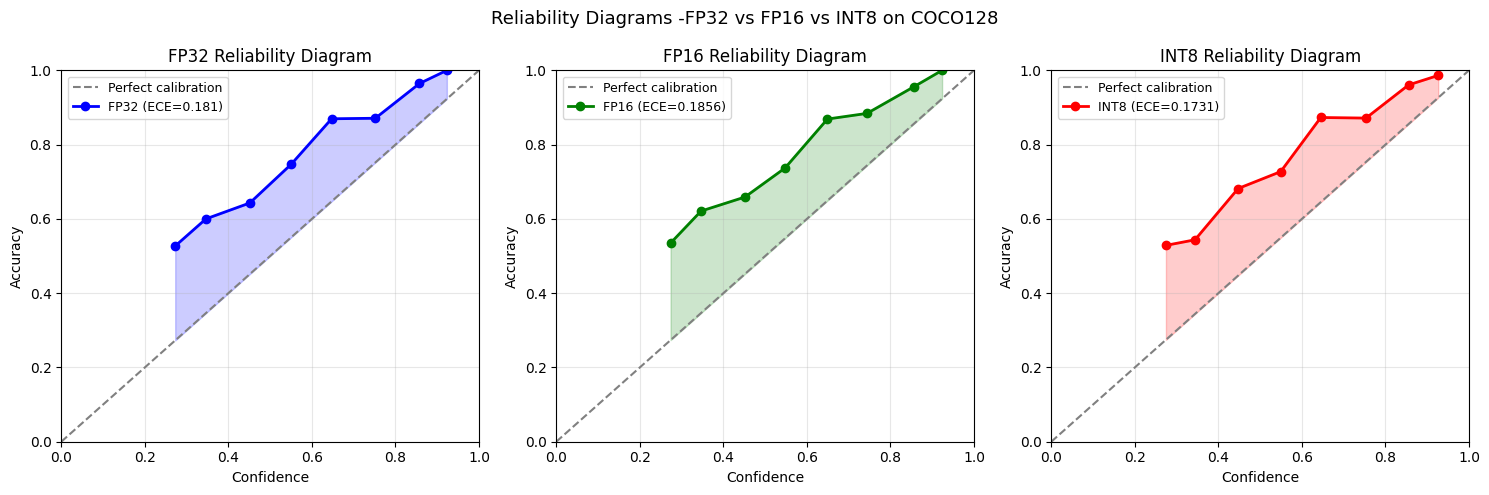

Saved: outputs/reliability_diagrams.jpg


In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_reliability(ax, df, model_name, ece, color):
    bins = np.linspace(0, 1, 11)

    bin_confidences = []
    bin_accuracies = []
    bin_sizes = []

    for i in range(10):
        in_bin = df[(df["confidence"] >= bins[i]) & (df["confidence"] < bins[i+1])]
        if len(in_bin) == 0:
            continue

        bin_confidences.append(in_bin["confidence"].mean())
        bin_accuracies.append(in_bin["correct"].mean())
        bin_sizes.append(len(in_bin))

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")

    ax.plot(bin_confidences, bin_accuracies, color = color, linewidth=2, marker="o", label=f"{model_name} (ECE={ece})")

    ax.fill_between(bin_confidences, bin_accuracies, bin_confidences, alpha=0.2, color=color)

    ax.set_title(f"{model_name} Reliability Diagram", fontsize=12)
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Accuracy")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_reliability(axes[0], fp32_coco, "FP32", fp32_ece, "blue")
plot_reliability(axes[1], fp16_coco, "FP16", fp16_ece, "green")
plot_reliability(axes[2], int8_coco, "INT8", int8_ece, "red")

plt.suptitle("Reliability Diagrams -FP32 vs FP16 vs INT8 on COCO128", fontsize=13)
plt.tight_layout()
plt.savefig("outputs/reliability_diagrams.jpg",dpi=300)
plt.show()
print("Saved: outputs/reliability_diagrams.jpg")
    

In [16]:
import os

os.makedirs("outputs", exist_ok=True)

fp32_coco.to_csv("outputs/fp32_coco_ece.csv", index=False)
fp16_coco.to_csv("outputs/fp16_coco_ece.csv", index=False)
int8_coco.to_csv("outputs/int8_coco_ece.csv", index=False)

print("CSVs saved to outputs folder")
print()

print("="*50)
print(f"{'ECE AND CALIBRATION SUMMARY':^50}")
print("="*50)
print(f"{'Model':<8} {'Detections':<13} {'Correct':<10} {'Accuracy':<12} {'ECE'}")
print("="*50)
print(f"{'FP32':<8} {len(fp32_coco):<13} {int(fp32_coco['correct'].sum()):<10} {round(fp32_coco['correct'].mean()*100, 1):<12} {fp32_ece}")
print(f"{'FP16':<8} {len(fp16_coco):<13} {int(fp16_coco['correct'].sum()):<10} {round(fp16_coco['correct'].mean()*100, 1):<12} {fp16_ece}")
print(f"{'INT8':<8} {len(int8_coco):<13} {int(int8_coco['correct'].sum()):<10} {round(int8_coco['correct'].mean()*100, 1):<12} {int8_ece}")
print("="*50)

CSVs saved to outputs folder

           ECE AND CALIBRATION SUMMARY            
Model    Detections    Correct    Accuracy     ECE
FP32     642           494        76.9         0.181
FP16     643           497        77.3         0.1856
INT8     663           504        76.0         0.1731
